In [ ]:
# aireacond.csv
import pandas as pd

# 1. Define archivo CSV
ruta_del_archivo = '../data_raw/aireacond.csv' 

# 2. Carga el archivo en un DataFrame
# (Intenta primero sin 'skiprows', a ver qué sale)
df = pd.read_csv(ruta_del_archivo)

# 3. Muestra las primeras 5 filas para inspeccionar
df.head()

,folio,foliohog,id_aire,aire_tipo,aire_otro,aire_capa,aire_dia,aire_ene,aire_feb,aire_mar,...,aire_jul,aire_ago,aire_sep,aire_oct,aire_nov,aire_dic,aire_hor,aire_min,aire_adqui,aire_anio
0,69,1,1,4,,9,42,,,,...,,,,,,,6,0,1,2
1,69,1,2,4,,9,42,,,,...,,,,,,,3,0,1,2
2,70,1,2,6,,9,30,,,,...,,,,,,,2,0,1,1
3,70,1,1,6,,9,90,,,,...,,,,,,,4,0,1,1
4,76,1,1,2,,9,60,,,,...,,,,,,,2,0,1,8


In [10]:
print(df.columns)

Index(['folio', 'foliohog', 'id_aire', 'aire_tipo', 'aire_otro', 'aire_capa',
       'aire_dia', 'aire_ene', 'aire_feb', 'aire_mar', 'aire_abr', 'aire_may',
       'aire_jun', 'aire_jul', 'aire_ago', 'aire_sep', 'aire_oct', 'aire_nov',
       'aire_dic', 'aire_hor', 'aire_min', 'aire_adqui', 'aire_anio'],
      dtype='object')


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7567 entries, 0 to 7566
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   folio       7567 non-null   int64 
 1   foliohog    7567 non-null   int64 
 2   id_aire     7567 non-null   int64 
 3   aire_tipo   7567 non-null   int64 
 4   aire_otro   7567 non-null   object
 5   aire_capa   7567 non-null   int64 
 6   aire_dia    7567 non-null   int64 
 7   aire_ene    7567 non-null   object
 8   aire_feb    7567 non-null   object
 9   aire_mar    7567 non-null   object
 10  aire_abr    7567 non-null   object
 11  aire_may    7567 non-null   object
 12  aire_jun    7567 non-null   object
 13  aire_jul    7567 non-null   object
 14  aire_ago    7567 non-null   object
 15  aire_sep    7567 non-null   object
 16  aire_oct    7567 non-null   object
 17  aire_nov    7567 non-null   object
 18  aire_dic    7567 non-null   object
 19  aire_hor    7567 non-null   int64 
 20  aire_min

In [12]:
# Primero, crea una lista con todas las columnas de meses
columnas_meses = ['aire_ene', 'aire_feb', 'aire_mar', 'aire_abr', 'aire_may', 
                  'aire_jun', 'aire_jul', 'aire_ago', 'aire_sep', 'aire_oct', 
                  'aire_nov', 'aire_dic']

# Ahora, itera por cada columna, reemplaza el valor 'raro' por 0 y convierte a número
for col in columnas_meses:
    # Reemplaza el valor o valores raros que encontraste (ej. '&') por un 0
    # Puedes añadir más cosas al diccionario si encuentras más, ej. {'&': 0, ' ': 0}
    df[col] = df[col].replace({'&': 0}) 
    
    # Forzamos la columna a que sea de tipo numérico
    # errors='coerce' es un truco: si algo no se puede convertir, lo pone como Nulo (NaN)
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Por si acaso, rellenamos cualquier Nulo que haya quedado con 0
    df[col] = df[col].fillna(0)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7567 entries, 0 to 7566
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   folio       7567 non-null   int64  
 1   foliohog    7567 non-null   int64  
 2   id_aire     7567 non-null   int64  
 3   aire_tipo   7567 non-null   int64  
 4   aire_otro   7567 non-null   object 
 5   aire_capa   7567 non-null   int64  
 6   aire_dia    7567 non-null   int64  
 7   aire_ene    7567 non-null   float64
 8   aire_feb    7567 non-null   float64
 9   aire_mar    7567 non-null   float64
 10  aire_abr    7567 non-null   float64
 11  aire_may    7567 non-null   float64
 12  aire_jun    7567 non-null   float64
 13  aire_jul    7567 non-null   float64
 14  aire_ago    7567 non-null   float64
 15  aire_sep    7567 non-null   float64
 16  aire_oct    7567 non-null   float64
 17  aire_nov    7567 non-null   float64
 18  aire_dic    7567 non-null   float64
 19  aire_hor    7567 non-null  

In [14]:
# Calcular el promedio de días y horas del año
promedio_dias_uso = df['aire_dia'].mean()
promedio_horas_uso = df['aire_hor'].mean()

print(f"En promedio, los hogares con A/C lo usan {promedio_dias_uso:.1f} días al mes.")
print(f"Y cuando lo usan, lo tienen encendido un promedio de {promedio_horas_uso:.1f} horas.")

En promedio, los hogares con A/C lo usan 171.7 días al mes.
Y cuando lo usan, lo tienen encendido un promedio de 7.3 horas.


Total de hogares que reportaron uso de A/C por mes:
aire_ene      773.0
aire_feb     2158.0
aire_mar     5967.0
aire_abr    13712.0
aire_may    30005.0
aire_jun    40602.0
aire_jul    48384.0
aire_ago    53632.0
aire_sep    47880.0
aire_oct    33900.0
aire_nov    15686.0
aire_dic     9192.0
dtype: float64


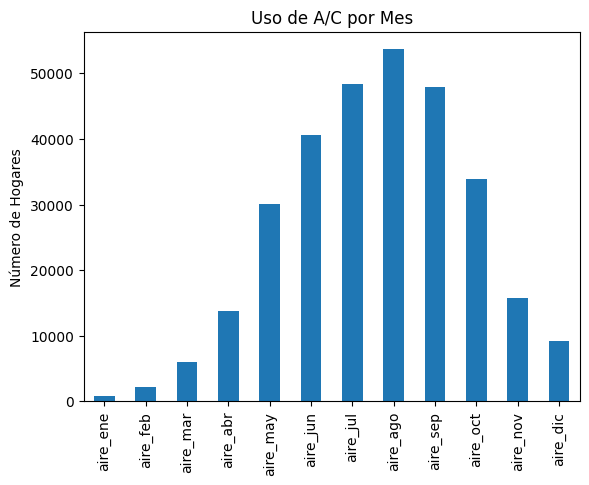

In [15]:
# Agrégala al inicio de la celda donde graficas
import matplotlib.pyplot as plt 

# --- Tu código que ya tenías ---
uso_por_mes = df[columnas_meses].sum()

print("Total de hogares que reportaron uso de A/C por mes:")
print(uso_por_mes)

# (Opcional) Verlo como un gráfico de barras
uso_por_mes.plot(kind='bar')
plt.title('Uso de A/C por Mes')
plt.ylabel('Número de Hogares')
plt.show()

In [16]:
print("Valores únicos en 'aire_otro':")
print(df['aire_otro'].unique())

Valores únicos en 'aire_otro':
[' ' 'COOLER' 'AIRE LAVADO' 'AEROCOOLERS' 'AEROCOLER' 'AIRE COOLER'
 'AERO COOLER' 'AEROCOOLER' 'APARATO DE AGUA' 'HEROCOOLERS'
 'EL EQUIPO ES DE AIRE LAVADO AEROCOOLER' 'AIRE COOLERS'
 'EL EQUIPO CON EL QUE CUENTAN ES UN APARATO DE AIRE'
 'EQUIPO DE AIRE LAVADO' 'EQUIPO AEROCOOLERS' 'AIRE LAVADO COOLERS'
 'ES AIRE LAVADO' 'AEROCULERS'
 'MULTI SPLIT  ES UN SOLO APARTO QUE ABASTECE DOS RE' 'MINISPLIT INVERTER'
 'AEROCOOLER NO SABE CAPACIDAD' 'COOLERS' 'CENTRAL']


In [17]:
# Se define la lista de columnas que sí importan
columnas_utiles = [
    'aire_tipo',     # Tipo de A/C (para reglas)
    'aire_capa',     # Capacidad (para reglas)
    'aire_dia',      # Días de uso al mes (para benchmark)
    'aire_hor',      # Horas de uso al día (para benchmark)
    'aire_anio',     # Año de adquisición (para reglas de eficiencia)
    'aire_ene', 'aire_feb', 'aire_mar', 'aire_abr', 'aire_may', 
    'aire_jun', 'aire_jul', 'aire_ago', 'aire_sep', 'aire_oct', 
    'aire_nov', 'aire_dic' # Para el patrón estacional
]

# Creamos el DataFrame final y limpio
df_limpio = df[columnas_utiles]

# Verificamos que se vea bien
df_limpio.head()

,aire_tipo,aire_capa,aire_dia,aire_hor,aire_anio,aire_ene,aire_feb,aire_mar,aire_abr,aire_may,aire_jun,aire_jul,aire_ago,aire_sep,aire_oct,aire_nov,aire_dic
0,4,9,42,6,2,0.0,0.0,0.0,4.0,5.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4,9,42,3,2,0.0,0.0,0.0,4.0,5.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0
2,6,9,30,2,1,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,6,9,90,4,1,0.0,0.0,0.0,4.0,5.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2,9,60,2,8,0.0,0.0,0.0,0.0,5.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
# Definimos la ruta de salida. Lo guardaremos en la carpeta raíz de tu proyecto.
ruta_salida = '../data_raw/data_clean/inegi_ac_limpio.csv' 

# Guardamos el archivo
# index=False es importante para no guardar el índice de pandas en el CSV
df_limpio.to_csv(ruta_salida, index=False)

print(f"¡Datos limpios guardados exitosamente en {ruta_salida}!")

¡Datos limpios guardados exitosamente en ../data_raw/data_clean/inegi_ac_limpio.csv!


In [2]:
# cal_agua.csv
import pandas as pd

# 1. Define la ruta al nuevo archivo
ruta_agua = '../data_raw/cal_agua.csv' 

# 2. Carga el archivo en un NUEVO DataFrame (lo llamaremos df_agua)
df_agua = pd.read_csv(ruta_agua)

# 3. Muestra las primeras 5 filas para inspeccionar
df_agua.head()

,folio,foliohog,id_cagua,cagua_tipo,cagua_capa,cagua_adqu,cagua_anio,cagua_mant
0,1,1,1,7,4,1,6,4
1,2,1,1,7,3,1,2,4
2,3,1,1,1,3,1,15,2
3,4,1,1,7,3,1,8,3
4,5,1,1,7,3,1,3,4


In [3]:
df_agua.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11454 entries, 0 to 11453
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   folio       11454 non-null  int64 
 1   foliohog    11454 non-null  int64 
 2   id_cagua    11454 non-null  int64 
 3   cagua_tipo  11454 non-null  int64 
 4   cagua_capa  11454 non-null  object
 5   cagua_adqu  11454 non-null  int64 
 6   cagua_anio  11454 non-null  int64 
 7   cagua_mant  11454 non-null  int64 
dtypes: int64(7), object(1)
memory usage: 716.0+ KB


In [5]:
print(f"Valores únicos en 'cagua_capa': {df_agua['cagua_capa'].unique()}")

Valores únicos en 'cagua_capa': ['4' '3' '1' ' ' '9' '2' '5' '6']


In [6]:
# Reemplaza el valor o valores raros que encontraste (ej. '&' y ' ') por un 0
# Asegúrate de reemplazar el valor exacto que viste en el Paso 1
df_agua['cagua_capa'] = df_agua['cagua_capa'].replace({'&': 0, ' ': 0}) 

# Forzamos la columna a que sea de tipo numérico
# errors='coerce' convierte cualquier error restante en Nulo (NaN)
df_agua['cagua_capa'] = pd.to_numeric(df_agua['cagua_capa'], errors='coerce')

# Rellenamos cualquier Nulo (NaN) que haya quedado con 0
df_agua['cagua_capa'] = df_agua['cagua_capa'].fillna(0)

In [7]:
df_agua.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11454 entries, 0 to 11453
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   folio       11454 non-null  int64
 1   foliohog    11454 non-null  int64
 2   id_cagua    11454 non-null  int64
 3   cagua_tipo  11454 non-null  int64
 4   cagua_capa  11454 non-null  int64
 5   cagua_adqu  11454 non-null  int64
 6   cagua_anio  11454 non-null  int64
 7   cagua_mant  11454 non-null  int64
dtypes: int64(8)
memory usage: 716.0 KB


In [8]:
# Reemplazamos el valor '&' por un 0.
df_agua['cagua_capa'] = df_agua['cagua_capa'].replace({'&': 0}) 

# Forzamos toda la columna a que sea de tipo numérico (int64)
df_agua['cagua_capa'] = pd.to_numeric(df_agua['cagua_capa'])

print("¡Columna 'cagua_capa' limpiada y convertida a número!")

¡Columna 'cagua_capa' limpiada y convertida a número!


In [9]:
df_agua.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11454 entries, 0 to 11453
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   folio       11454 non-null  int64
 1   foliohog    11454 non-null  int64
 2   id_cagua    11454 non-null  int64
 3   cagua_tipo  11454 non-null  int64
 4   cagua_capa  11454 non-null  int64
 5   cagua_adqu  11454 non-null  int64
 6   cagua_anio  11454 non-null  int64
 7   cagua_mant  11454 non-null  int64
dtypes: int64(8)
memory usage: 716.0 KB


In [10]:
# Vamos a ver los códigos únicos para el tipo de calentador
print(f"Códigos únicos en 'cagua_tipo': {df_agua['cagua_tipo'].unique()}")

# Y también los códigos para el tipo de adquisición
print(f"Códigos únicos en 'cagua_adqu': {df_agua['cagua_adqu'].unique()}")

# Y los códigos de mantenimiento
print(f"Códigos únicos en 'cagua_mant': {df_agua['cagua_mant'].unique()}")

Códigos únicos en 'cagua_tipo': [7 1 3 4 2 5 6 8]
Códigos únicos en 'cagua_adqu': [1 2]
Códigos únicos en 'cagua_mant': [4 2 3 1]


In [13]:
# Paso 1: Crear los diccionarios de traducción (basado en las imágenes)

# Diccionario para: cagua_tipo (Tipo de calentador)
traductor_tipo = {
    1: 'De gas con deposito',
    2: 'De gas de rápida recuperación',
    3: 'De gas instantáneo de paso',
    4: 'Eléctrico instantáneo de paso',
    5: 'Eléctrico con depósito',
    6: 'De leña',
    7: 'Solar',
    8: 'Otro tipo de calentador (especificar)'
}

# Diccionario para: cagua_capa (Capacidad del calentador)
traductor_capa = {
    1: 'De 38 a 40 litros (hasta 2 personas)',
    2: 'De 50 a 60 litros (hasta 3 personas)',
    3: 'De 70 a 80 litros (hasta 4 personas)',
    4: 'De 90 a 110 litros (hasta 6 personas)',
    5: 'De 120 a 140 litros (hasta 7 personas)',
    6: 'Más de 140 litros (más de 7 personas)',
    9: 'No sabe'
}

# Diccionario para: cagua_adqu (Modo de adquisición)
traductor_adqu = {
    1: 'Nuevo',
    2: 'Usado'
}

# Diccionario para: cagua_mant (Mantenimiento)
# Este diccionario ahora incluye todas las claves de la imagen
traductor_mant = {
    1: 'Cada 6 meses',
    2: 'Cada año',
    3: 'Cada 2 años',
    4: 'No le da mantenimiento'
}

# --- FIN DE LOS DICCIONARIOS ---

# Paso 2: Aplicar las traducciones a tu DataFrame
# (Usamos .map() que es la forma correcta de aplicar un diccionario)

# Creamos nuevas columnas con el sufijo '_desc' para guardar el texto
df_agua['cagua_tipo_desc'] = df_agua['cagua_tipo'].map(traductor_tipo)
df_agua['cagua_capa_desc'] = df_agua['cagua_capa'].map(traductor_capa)
df_agua['cagua_adqu_desc'] = df_agua['cagua_adqu'].map(traductor_adqu)
df_agua['cagua_mant_desc'] = df_agua['cagua_mant'].map(traductor_mant)

print("¡Traducción aplicada! Se crearon 4 nuevas columnas descriptivas.")

# Paso 3: Inspeccionar el resultado
# Se imprime el .head() del DataFrame para verificar que las nuevas 
# columnas de descripción se hayan añadido correctamente.
print("DataFrame con las nuevas columnas de descripción:")
df_agua.head()

¡Traducción aplicada! Se crearon 4 nuevas columnas descriptivas.
DataFrame con las nuevas columnas de descripción:


,folio,foliohog,id_cagua,cagua_tipo,cagua_capa,cagua_adqu,cagua_anio,cagua_mant,cagua_tipo_desc,cagua_adqu_desc,cagua_mant_desc,cagua_capa_desc
0,1,1,1,7,4,1,6,4,Solar,Nuevo,No le da mantenimiento,De 90 a 110 litros (hasta 6 personas)
1,2,1,1,7,3,1,2,4,Solar,Nuevo,No le da mantenimiento,De 70 a 80 litros (hasta 4 personas)
2,3,1,1,1,3,1,15,2,De gas con deposito,Nuevo,Cada año,De 70 a 80 litros (hasta 4 personas)
3,4,1,1,7,3,1,8,3,Solar,Nuevo,Cada 2 años,De 70 a 80 litros (hasta 4 personas)
4,5,1,1,7,3,1,3,4,Solar,Nuevo,No le da mantenimiento,De 70 a 80 litros (hasta 4 personas)


In [14]:
df_agua.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11454 entries, 0 to 11453
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   folio            11454 non-null  int64 
 1   foliohog         11454 non-null  int64 
 2   id_cagua         11454 non-null  int64 
 3   cagua_tipo       11454 non-null  int64 
 4   cagua_capa       11454 non-null  int64 
 5   cagua_adqu       11454 non-null  int64 
 6   cagua_anio       11454 non-null  int64 
 7   cagua_mant       11454 non-null  int64 
 8   cagua_tipo_desc  11454 non-null  object
 9   cagua_adqu_desc  11454 non-null  object
 10  cagua_mant_desc  11454 non-null  object
 11  cagua_capa_desc  8180 non-null   object
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [17]:
# Contamos cuántas veces aparece CADA tipo de calentador en todo el dataset
print("Distribución total de 'cagua_tipo_desc':")
df_agua['cagua_tipo_desc'].value_counts()


Distribución total de 'cagua_tipo_desc':


cagua_tipo_desc
De gas con deposito                      5206
Solar                                    1916
De gas instantáneo de paso               1740
De gas de rápida recuperación            1201
De leña                                   680
Eléctrico con depósito                    370
Eléctrico instantáneo de paso             333
Otro tipo de calentador (especificar)       8
Name: count, dtype: int64

In [19]:
print("\nDistribución total de 'cagua_capa_desc':")
df_agua['cagua_capa_desc'].value_counts()


Distribución total de 'cagua_capa_desc':


cagua_capa_desc
De 38 a 40 litros (hasta 2 personas)      2977
De 70 a 80 litros (hasta 4 personas)      1709
De 50 a 60 litros (hasta 3 personas)      1335
No sabe                                    982
De 90 a 110 litros (hasta 6 personas)      832
Más de 140 litros (más de 7 personas)      188
De 120 a 140 litros (hasta 7 personas)     157
Name: count, dtype: int64

In [20]:
print("\nDistribución total de 'cagua_adqu_desc':")
df_agua['cagua_adqu_desc'].value_counts()


Distribución total de 'cagua_adqu_desc':


cagua_adqu_desc
Nuevo    9897
Usado    1557
Name: count, dtype: int64

In [22]:
print("\nDistribución total de 'cagua_mant_desc':")
df_agua['cagua_mant_desc'].value_counts()


Distribución total de 'cagua_mant_desc':


cagua_mant_desc
No le da mantenimiento    6178
Cada 6 meses              2469
Cada año                  2225
Cada 2 años                582
Name: count, dtype: int64

In [23]:
# Definimos la ruta de salida exacta
ruta_salida_agua = '../data_raw/data_clean/inegi_cal_agua_limpio.csv' 

# Guardamos el archivo (index=False es importante)
df_agua.to_csv(ruta_salida_agua, index=False)

print(f"¡Datos limpios de cal_agua guardados exitosamente en {ruta_salida_agua}!")

¡Datos limpios de cal_agua guardados exitosamente en ../data_raw/data_clean/inegi_cal_agua_limpio.csv!


In [5]:
# calefactor.csv
import pandas as pd
# 1. Define la ruta al nuevo archivo
ruta_calefactor = '../data_raw/calefactor.csv'

# 2. Carga el archivo en un NUEVO DataFrame (lo llamaremos df_calefactor)
df_calefactor = pd.read_csv(ruta_calefactor)

# 3. Muestra las primeras 5 filas para inspeccionar
df_calefactor.head()

,folio,foliohog,id_calefac,calef_tipo,calef_otro,calef_dia,calef_hor,calef_min,calef_adqu,calef_anio
0,28,1,1,1,,10,3,0,1,9
1,39,1,1,2,,30,8,0,1,1
2,57,1,1,3,,6,1,0,1,10
3,58,1,1,3,,30,4,0,1,4
4,68,1,1,1,,60,3,0,1,1


In [6]:
df_calefactor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2142 entries, 0 to 2141
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   folio       2142 non-null   int64 
 1   foliohog    2142 non-null   int64 
 2   id_calefac  2142 non-null   int64 
 3   calef_tipo  2142 non-null   int64 
 4   calef_otro  2142 non-null   object
 5   calef_dia   2142 non-null   int64 
 6   calef_hor   2142 non-null   int64 
 7   calef_min   2142 non-null   int64 
 8   calef_adqu  2142 non-null   int64 
 9   calef_anio  2142 non-null   int64 
dtypes: int64(9), object(1)
memory usage: 167.5+ KB


In [7]:
# Vamos a ver los códigos únicos para el tipo de calefactor
print(f"Códigos únicos en 'calef_tipo': {df_calefactor['calef_tipo'].unique()}")

# Y también los códigos para el tipo de adquisición
print(f"Códigos únicos en 'calef_adqu': {df_calefactor['calef_adqu'].unique()}")

Códigos únicos en 'calef_tipo': [1 2 3 4 5 9]
Códigos únicos en 'calef_adqu': [1 2]


In [8]:
# Paso 1: Crear los diccionarios de traducción (basado en tus datos)
traductor_calef_tipo = {
    1: 'Eléctrico con aceite térmico',
    2: 'Eléctrico de resistencia',
    3: 'Eléctrico de torre',
    4: 'De gas',
    5: 'Otro tipo de calefactor (especifica)',
    9: 'No sabe'
}

traductor_calef_adqu = {
    1: 'Nuevo',
    2: 'Usado'
}

# Paso 2: Aplicar las traducciones a tu DataFrame
df_calefactor['calef_tipo_desc'] = df_calefactor['calef_tipo'].map(traductor_calef_tipo)
df_calefactor['calef_adqu_desc'] = df_calefactor['calef_adqu'].map(traductor_calef_adqu)


# Paso 3: Inspeccionar el resultado
print("\nDataFrame con las nuevas columnas de descripción:")
df_calefactor.head()


DataFrame con las nuevas columnas de descripción:


,folio,foliohog,id_calefac,calef_tipo,calef_otro,calef_dia,calef_hor,calef_min,calef_adqu,calef_anio,calef_tipo_desc,calef_adqu_desc
0,28,1,1,1,,10,3,0,1,9,Eléctrico con aceite térmico,Nuevo
1,39,1,1,2,,30,8,0,1,1,Eléctrico de resistencia,Nuevo
2,57,1,1,3,,6,1,0,1,10,Eléctrico de torre,Nuevo
3,58,1,1,3,,30,4,0,1,4,Eléctrico de torre,Nuevo
4,68,1,1,1,,60,3,0,1,1,Eléctrico con aceite térmico,Nuevo


In [9]:
print("\nDistribución total de 'calef_tipo_desc':")
df_calefactor['calef_tipo_desc'].value_counts()


Distribución total de 'calef_tipo_desc':


calef_tipo_desc
De gas                                  637
Eléctrico de resistencia                597
Otro tipo de calefactor (especifica)    487
Eléctrico con aceite térmico            234
Eléctrico de torre                      184
No sabe                                   3
Name: count, dtype: int64

In [10]:
# Definimos la ruta de salida en tu carpeta 'data_clean'
ruta_salida_calefactor = '../data_raw/data_clean/inegi_calefactor_limpio.csv' 

# Guardamos el archivo (index=False es importante)
df_calefactor.to_csv(ruta_salida_calefactor, index=False)

print(f"¡Datos limpios de calefactor guardados exitosamente en {ruta_salida_calefactor}!")

¡Datos limpios de calefactor guardados exitosamente en ../data_raw/data_clean/inegi_calefactor_limpio.csv!


In [11]:
# cambio.csv
import pandas as pd
# 1. Define la ruta al nuevo archivo
ruta_cambio = '../data_raw/cambio.csv'
# 2. Carga el archivo en un NUEVO DataFrame (lo llamaremos df_cambio)
df_cambio = pd.read_csv(ruta_cambio)
# 3. Muestra las primeras 5 filas para inspeccionar
df_cambio.head()

,folio,foliohog,id_cambio,camb_apara,criterio1,criterio2
0,1,1,1,2,,
1,1,1,2,2,,
2,1,1,3,2,,
3,1,1,4,2,,
4,2,1,3,2,,


In [12]:
df_cambio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115812 entries, 0 to 115811
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   folio       115812 non-null  int64 
 1   foliohog    115812 non-null  int64 
 2   id_cambio   115812 non-null  int64 
 3   camb_apara  115812 non-null  int64 
 4   criterio1   115812 non-null  object
 5   criterio2   115812 non-null  object
dtypes: int64(4), object(2)
memory usage: 5.3+ MB


In [13]:
print(f"Valores únicos en 'criterio1': {df_cambio['criterio1'].unique()}")
print(f"Valores únicos en 'criterio2': {df_cambio['criterio2'].unique()}")

Valores únicos en 'criterio1': [' ' '2' '5' '1' '4' '3']
Valores únicos en 'criterio2': [' ' '1' '3' '2' '5' '4']


In [14]:
# Lista de las columnas que SÍ son un problema
columnas_a_limpiar = ['criterio1', 'criterio2']

# Itera por cada columna, reemplaza el valor 'raro' por 0 y convierte a número
for col in columnas_a_limpiar:
    # Reemplaza el valor o valores raros que encontraste (ej. '&' y ' ') por 0
    df_cambio[col] = df_cambio[col].replace({'&': 0, ' ': 0}) 
    
    # Forzamos la columna a que sea de tipo numérico
    # errors='coerce' convierte cualquier error restante en Nulo (NaN)
    df_cambio[col] = pd.to_numeric(df_cambio[col], errors='coerce')
    
    # Rellenamos cualquier Nulo (NaN) que haya quedado con 0
    df_cambio[col] = df_cambio[col].fillna(0)

print("¡Columnas 'criterio1' y 'criterio2' limpiadas!")

¡Columnas 'criterio1' y 'criterio2' limpiadas!


In [15]:
df_cambio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115812 entries, 0 to 115811
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   folio       115812 non-null  int64
 1   foliohog    115812 non-null  int64
 2   id_cambio   115812 non-null  int64
 3   camb_apara  115812 non-null  int64
 4   criterio1   115812 non-null  int64
 5   criterio2   115812 non-null  int64
dtypes: int64(6)
memory usage: 5.3 MB


In [16]:
# Inspeccionar los códigos únicos
print(f"Códigos en 'camb_apara': {df_cambio['camb_apara'].unique()}")
print(f"Códigos en 'criterio1': {df_cambio['criterio1'].unique()}")
print(f"Códigos en 'criterio2': {df_cambio['criterio2'].unique()}")

Códigos en 'camb_apara': [2 1 9]
Códigos en 'criterio1': [0 2 5 1 4 3]
Códigos en 'criterio2': [0 1 3 2 5 4]


In [17]:
# Paso 1: Crear los diccionarios de traducción (basado en tus datos)
traductor_aparato = {
    1: 'Sí',
    2: 'No',
    9: 'No sabe'
}

# (¡REVISA EL PDF PARA EL CÓDIGO 1 y 0!)
traductor_criterio1 = {
    0: 'No aplica', # Suposición, ajusta con el PDF
    1: 'Precio',    # Suposición, ajusta con el PDF
    2: 'Consumo de energía (o combustible)',
    3: 'Marca',
    4: 'Tamaño',
    5: 'Funciones o cualidades adicionales'
}

# (¡REVISA EL PDF PARA EL CÓDIGO 0!)
traductor_criterio2 = {
    0: 'No aplica', # Suposición, ajusta con el PDF
    1: 'Precio',
    2: 'Consumo de energía (o combustible)',
    3: 'Marca',
    4: 'Tamaño',
    5: 'Funciones o cualidades adicionales'
}

# Paso 2: Aplicar las traducciones a tu DataFrame
df_cambio['camb_apara_desc'] = df_cambio['camb_apara'].map(traductor_aparato)
df_cambio['criterio1_desc'] = df_cambio['criterio1'].map(traductor_criterio1)
df_cambio['criterio2_desc'] = df_cambio['criterio2'].map(traductor_criterio2)


# Paso 3: Inspeccionar el resultado
print("\nDataFrame con las nuevas columnas de descripción:")
df_cambio.head()


DataFrame con las nuevas columnas de descripción:


,folio,foliohog,id_cambio,camb_apara,criterio1,criterio2,camb_apara_desc,criterio1_desc,criterio2_desc
0,1,1,1,2,0,0,No,No aplica,No aplica
1,1,1,2,2,0,0,No,No aplica,No aplica
2,1,1,3,2,0,0,No,No aplica,No aplica
3,1,1,4,2,0,0,No,No aplica,No aplica
4,2,1,3,2,0,0,No,No aplica,No aplica


In [18]:
# Definimos la ruta de salida en tu carpeta 'data_clean'
ruta_salida_cambio = '../data_raw/data_clean/inegi_cambio_limpio.csv' 

# Guardamos el archivo (index=False es importante)
df_cambio.to_csv(ruta_salida_cambio, index=False)

print(f"¡Datos limpios de cambio guardados exitosamente en {ruta_salida_cambio}!")

¡Datos limpios de cambio guardados exitosamente en ../data_raw/data_clean/inegi_cambio_limpio.csv!


In [19]:
# electro.csv
# 1. Define la ruta al nuevo archivo
ruta_electro = '../data_raw/electro.csv' 

# 2. Carga el archivo en un NUEVO DataFrame (lo llamaremos df_electro)
df_electro = pd.read_csv(ruta_electro)

# 3. Muestra las primeras 5 filas para inspeccionar
df_electro.head()

,folio,foliohog,id_electro,elect_uso,elect_dia,elect_hor,elect_min,elect_anio
0,1,1,1,1,10,00,05,02
1,1,1,2,1,4,00,03,04
2,1,1,3,2,,,,
3,1,1,4,2,,,,
4,1,1,6,2,,,,


In [20]:
df_electro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287690 entries, 0 to 287689
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   folio       287690 non-null  int64 
 1   foliohog    287690 non-null  int64 
 2   id_electro  287690 non-null  int64 
 3   elect_uso   287690 non-null  int64 
 4   elect_dia   287690 non-null  object
 5   elect_hor   287690 non-null  object
 6   elect_min   287690 non-null  object
 7   elect_anio  287690 non-null  object
dtypes: int64(4), object(4)
memory usage: 17.6+ MB


In [21]:
# En una nueva celda, ejecuta esto:
print(f"Valores únicos en 'elect_dia': {df_electro['elect_dia'].unique()}")
print(f"Valores únicos en 'elect_hor': {df_electro['elect_hor'].unique()}")
print(f"Valores únicos en 'elect_min': {df_electro['elect_min'].unique()}")
print(f"Valores únicos en 'elect_anio': {df_electro['elect_anio'].unique()}")

Valores únicos en 'elect_dia': ['10' '4' ' ' '15' '12' '20' '30' '8' '5' '6' '1' '2' '16' '3' '7' '25'
 '24' '26' '18' '17' '9' '99' '22' '21' '11' '14' '28' '27' '13' '23' '98'
 '19' '29']
Valores únicos en 'elect_hor': ['00' ' ' '06' '02' '01' '03' '99' '04' '10' '05' '08' '09' '15' '12' '07'
 '24' '16' '11' '20']
Valores únicos en 'elect_min': ['05' '03' ' ' '15' '10' '02' '30' '00' '20' '04' '06' '99' '01' '07' '45'
 '40' '08' '25' '24' '50' '32' '18' '22' '35' '16' '12' '13' '19' '09'
 '23' '55' '59' '21' '27' '58' '14' '17' '11' '33' '49' '39']
Valores únicos en 'elect_anio': ['02' '04' ' ' '05' '03' '01' '10' '07' '99' '17' '28' '15' '18' '22' '06'
 '50' '16' '08' '20' '30' '12' '09' '35' '25' '19' '27' '11' '13' '26'
 '40' '14' '23' '24' '33' '21' '32' '41' '46' '98' '38' '45' '29' '36'
 '42']


In [22]:
# Lista de las columnas que SÍ son un problema
columnas_a_limpiar = ['elect_dia', 'elect_hor', 'elect_min', 'elect_anio']

# Itera por cada columna, reemplaza el valor 'raro' por 0 y convierte a número
for col in columnas_a_limpiar:
    # Reemplaza el valor o valores raros que encontraste (ej. '&' y ' ') por 0
    df_electro[col] = df_electro[col].replace({'&': 0, ' ': 0}) 
    
    # Forzamos la columna a que sea de tipo numérico
    # errors='coerce' convierte cualquier error restante en Nulo (NaN)
    df_electro[col] = pd.to_numeric(df_electro[col], errors='coerce')
    
    # Rellenamos cualquier Nulo (NaN) que haya quedado con 0
    df_electro[col] = df_electro[col].fillna(0)

print("¡Columnas de 'electro' limpiadas!")

¡Columnas de 'electro' limpiadas!


In [23]:
df_electro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287690 entries, 0 to 287689
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   folio       287690 non-null  int64
 1   foliohog    287690 non-null  int64
 2   id_electro  287690 non-null  int64
 3   elect_uso   287690 non-null  int64
 4   elect_dia   287690 non-null  int64
 5   elect_hor   287690 non-null  int64
 6   elect_min   287690 non-null  int64
 7   elect_anio  287690 non-null  int64
dtypes: int64(8)
memory usage: 17.6 MB


In [25]:
# Vamos a ver los códigos únicos para el tipo de electrodoméstico
print(f"Códigos únicos en 'elect_uso': {df_electro['elect_uso'].unique()}")
print(f"Códigos únicos en 'elect_uso': {df_electro['id_electro'].unique()}")

Códigos únicos en 'elect_uso': [1 2]
Códigos únicos en 'elect_uso': [ 1  2  3  4  6 10  9  8  7  5]


In [26]:
# Este traductor es para la columna 'id_electro'
traductor_id_electro = {
    1: 'Horno de microondas',
    2: 'Licuadora',
    3: 'Batidora',
    4: 'Cafetera',
    5: 'Tostador de pan o sandwichera',
    6: 'Parrilla eléctrica u horno eléctrico',
    7: 'Secadora de pelo',
    8: 'Tenazas o plancha para el pelo',
    9: 'Secadora de ropa',
    10: 'Máquina de coser eléctrica'
}

# Este traductor es para la columna 'elect_uso'
traductor_elect_uso = {
    1: 'Sí',
    2: 'No'
}

# Paso 2: Aplicar las traducciones a las columnas correctas
df_electro['electro_desc'] = df_electro['id_electro'].map(traductor_id_electro)
df_electro['uso_desc'] = df_electro['elect_uso'].map(traductor_elect_uso)


# Paso 3: Inspeccionar el resultado
print("\nDataFrame con las nuevas columnas de descripción:")
df_electro.head()


DataFrame con las nuevas columnas de descripción:


,folio,foliohog,id_electro,elect_uso,elect_dia,elect_hor,elect_min,elect_anio,electro_desc,uso_desc
0,1,1,1,1,10,0,5,2,Horno de microondas,Sí
1,1,1,2,1,4,0,3,4,Licuadora,Sí
2,1,1,3,2,0,0,0,0,Batidora,No
3,1,1,4,2,0,0,0,0,Cafetera,No
4,1,1,6,2,0,0,0,0,Parrilla eléctrica u horno eléctrico,No


In [28]:
# Filtramos el DataFrame para ver solo las filas donde 'uso_desc' es 'Sí'
df_electro_que_si_tienen = df_electro[df_electro['uso_desc'] == 'Sí']

# Ahora sí, contamos los aparatos de ese DataFrame filtrado
print("Total de hogares que SÍ TIENEN cada aparato:")
df_electro_que_si_tienen['electro_desc'].value_counts()

Total de hogares que SÍ TIENEN cada aparato:


electro_desc
Licuadora                               24776
Horno de microondas                     10297
Tenazas o plancha para el pelo           5693
Batidora                                 4263
Secadora de pelo                         3995
Tostador de pan o sandwichera            2606
Cafetera                                 2530
Parrilla eléctrica u horno eléctrico     1690
Secadora de ropa                         1678
Máquina de coser eléctrica               1455
Name: count, dtype: int64

In [29]:
# Definimos la ruta de salida en tu carpeta 'data_clean'
ruta_salida_electro = '../data_raw/data_clean/inegi_electro_limpio.csv' 

# Guardamos el DataFrame 'df_electro' (que tiene las nuevas columnas _desc)
df_electro.to_csv(ruta_salida_electro, index=False)

print(f"¡Datos limpios de electro guardados exitosamente en {ruta_salida_electro}!")

¡Datos limpios de electro guardados exitosamente en ../data_raw/data_clean/inegi_electro_limpio.csv!


In [31]:
# encevi.csv
# 1. Define la ruta al nuevo archivo
ruta_encevi = '../data_raw/encevi.csv' 

# 2. Carga el archivo en un NUEVO DataFrame (lo llamaremos df_encevi)
df_encevi = pd.read_csv(ruta_encevi)

# 3. Muestra las primeras 5 filas para inspeccionar
df_encevi.head()

C:\Users\jonat\AppData\Local\Temp\ipykernel_4956\472510203.py:6: DtypeWarning: Columns (51) have mixed types. Specify dtype option on import or set low_memory=False.
  df_encevi = pd.read_csv(ruta_encevi)


,folio,foliohog,tipo_viv,elevador,total_niv,mat_pared,mat_techo,mat_piso,ais_techo,ais_tech_c,...,salud_gas,salud_nat,ambi_lenia,ambi_gas,ambi_nat,ambi_gasol,agota_gas,afecta_gas,energi_sol,mej_habito
0,1,1,1,,2,8,10,3,2,,...,2,3,1,2,2,1,2,1,1,1
1,2,1,1,,1,8,10,3,2,,...,3,3,1,3,3,1,1,2,2,1
2,3,1,1,,2,8,10,3,2,,...,4,4,1,4,4,1,2,2,1,1
3,4,1,1,,1,8,10,3,2,,...,4,2,1,3,3,1,2,2,1,1
4,5,1,1,,1,8,10,3,2,,...,3,3,1,3,3,1,1,2,2,1


In [32]:
df_encevi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28953 entries, 0 to 28952
Columns: 228 entries, folio to mej_habito
dtypes: int64(49), object(179)
memory usage: 50.4+ MB


In [34]:
# Imprime la lista completa de las 228 columnas
print(list(df_encevi.columns))

['folio', 'foliohog', 'tipo_viv', 'elevador', 'total_niv', 'mat_pared', 'mat_techo', 'mat_piso', 'ais_techo', 'ais_tech_c', 'ais_pared', 'ais_pare_c', 'ais_venta', 'ais_vent_c', 'ais_otro', 'ais_otro_e', 'ta_venta', 'ta_otro', 'antigua', 'super_ter', 'super_cons', 'cocina', 'cuart_dorm', 'tot_cuart', 'disp_agua', 'tenencia', 'ant_resid', 'electri', 'local_com', 'elect_loc', 'cons_med1', 'cons_med2', 'inicia1', 'mes_inic1', 'final1', 'mes_final1', 'inicia2', 'mes_inic2', 'final2', 'mes_final2', 'tipo_tarif', 'cond_energ', 'otra_energ', 'energ_alt', 'anio_comp', 'pot_panel', 'comb_plan', 'pot_fluor', 'eq_focos_f', 'pot_led', 'eq_focos_l', 'pot_incan', 'hora_enc', 'min_enc', 'hora_apag', 'min_apag', 'combus_c', 'otro_c', 'combus_s', 'otro_s', 'cons_gas', 'gasto_gas', 'mes_gas', 'anio_gas', 'period_gas', 'cons_est', 'med_est', 'gasto_est', 'mes_est', 'anio_est', 'period_est', 'gasto_nat', 'd_inic_nat', 'm_inic_nat', 'd_fin_nat', 'm_fin_nat', 'cons_nat', 'cons_lenia', 'gasto_len', 'cons_car

In [35]:
# --- AJUSTA ESTOS NOMBRES si encuentras otros mejores en la lista ---
columna_consumo = 'cons_med1' 
columna_tarifa = 'tipo_tarif'
columna_vivienda = 'tipo_viv'
# -----------------------------

# Inspeccionamos los valores "raros" SÓLO en esas columnas
print(f"Valores únicos en Consumo ({columna_consumo}): {df_encevi[columna_consumo].unique()}")
print(f"Valores únicos en Tarifa ({columna_tarifa}): {df_encevi[columna_tarifa].unique()}")
print(f"Valores únicos en Vivienda ({columna_vivienda}): {df_encevi[columna_vivienda].unique()}")

Valores únicos en Consumo (cons_med1): ['261' '150' '500' ... '1577' '719' '2673']
Valores únicos en Tarifa (tipo_tarif): ['1' ' ' '9' '8' '0' '2' '7' '6' '5' '4' '3']
Valores únicos en Vivienda (tipo_viv): [1 2 3 6 4 7 5]


In [36]:
# --- AJUSTA EL NOMBRE DE LA COLUMNA SI ES NECESARIO ---
columnas_a_limpiar = [columna_consumo] 

# Itera y limpia SÓLO esa columna
for col in columnas_a_limpiar:
    # Reemplaza el valor o valores raros que encontraste (ej. '&' y ' ') por 0
    df_encevi[col] = df_encevi[col].replace({'&': 0, ' ': 0}) 
    
    # Forzamos la columna a que sea de tipo numérico
    df_encevi[col] = pd.to_numeric(df_encevi[col], errors='coerce')
    
    # Rellenamos cualquier Nulo (NaN) que haya quedado con 0
    df_encevi[col] = df_encevi[col].fillna(0)

print(f"¡Columna {columna_consumo} limpiada!")

¡Columna cons_med1 limpiada!


In [37]:
# --- Definimos las columnas que queremos espiar ---
columna_consumo = 'cons_med1' 
columna_tarifa = 'tipo_tarif'
columna_vivienda = 'tipo_viv'

# --- Inspeccionamos los valores únicos SÓLO en esas columnas ---
# .unique() nos da una lista de todos los valores diferentes que existen

print(f"Valores únicos en Consumo ({columna_consumo}):")
print(df_encevi[columna_consumo].unique())

print(f"\nValores únicos en Tarifa ({columna_tarifa}):")
print(df_encevi[columna_tarifa].unique())

print(f"\nValores únicos en Vivienda ({columna_vivienda}):")
print(df_encevi[columna_vivienda].unique())

Valores únicos en Consumo (cons_med1):
[ 261  150  500 ... 1577  719 2673]

Valores únicos en Tarifa (tipo_tarif):
['1' ' ' '9' '8' '0' '2' '7' '6' '5' '4' '3']

Valores únicos en Vivienda (tipo_viv):
[1 2 3 6 4 7 5]


In [38]:
# Lista de columnas de códigos que están como texto
columnas_a_limpiar = ['tipo_tarif'] 

# Limpiamos
for col in columnas_a_limpiar:
    # Reemplazamos el espacio ' ' y el '&' (por si acaso) con 0
    # Usamos 0 porque en tu diccionario 0 = '02', es un valor válido
    df_encevi[col] = df_encevi[col].replace({' ': 0, '&': 0}) 
    
    df_encevi[col] = pd.to_numeric(df_encevi[col], errors='coerce')
    df_encevi[col] = df_encevi[col].fillna(0)

# Convertimos ambas columnas a tipo 'int' para que coincidan con los diccionarios
df_encevi['tipo_tarif'] = df_encevi['tipo_tarif'].astype(int)
df_encevi['tipo_viv'] = df_encevi['tipo_viv'].astype(int)

print("¡Columnas 'tipo_tarif' y 'tipo_viv' limpiadas y listas para traducir!")

¡Columnas 'tipo_tarif' y 'tipo_viv' limpiadas y listas para traducir!


In [39]:
# Paso 1: Crear los diccionarios de traducción (basado en tus datos)
traductor_tarifa = {
    0: '02',
    1: '01',
    2: '1 - A',
    3: '1 - B',
    4: '1 - C',
    5: '1 - D',
    6: '1 - E',
    7: '1 - F',
    8: 'DAC',
    9: 'No sabe'
}

traductor_vivienda = {
    1: 'Casa única del terreno',
    2: 'Casa que comparte terreno con otra(s)',
    3: 'Casa dúplex, triple o cuádruple',
    4: 'Departamento en edificio',
    5: 'Cuarto en la azotea de un edificio',
    6: 'Vivienda en vecindad o cuartería',
    7: 'Local no construido para habitación'
}

# Paso 2: Aplicar las traducciones a tu DataFrame
df_encevi['tarifa_desc'] = df_encevi['tipo_tarif'].map(traductor_tarifa)
df_encevi['vivienda_desc'] = df_encevi['tipo_viv'].map(traductor_vivienda)


# Paso 3: Inspeccionar el resultado
print("\nDataFrame con las nuevas columnas de descripción:")
df_encevi.head()


DataFrame con las nuevas columnas de descripción:


,folio,foliohog,tipo_viv,elevador,total_niv,mat_pared,mat_techo,mat_piso,ais_techo,ais_tech_c,...,ambi_lenia,ambi_gas,ambi_nat,ambi_gasol,agota_gas,afecta_gas,energi_sol,mej_habito,tarifa_desc,vivienda_desc
0,1,1,1,,2,8,10,3,2,,...,1,2,2,1,2,1,1,1,01,Casa única del terreno
1,2,1,1,,1,8,10,3,2,,...,1,3,3,1,1,2,2,1,01,Casa única del terreno
2,3,1,1,,2,8,10,3,2,,...,1,4,4,1,2,2,1,1,01,Casa única del terreno
3,4,1,1,,1,8,10,3,2,,...,1,3,3,1,2,2,1,1,01,Casa única del terreno
4,5,1,1,,1,8,10,3,2,,...,1,3,3,1,1,2,2,1,01,Casa única del terreno


In [40]:
# --- AJUSTA ESTE NOMBRE si es necesario ---
columna_consumo = 'cons_med1' 

# Reemplaza los valores "raros" ('&' y ' ') por 0
df_encevi[columna_consumo] = df_encevi[columna_consumo].replace({'&': 0, ' ': 0}) 

# Forzamos la columna a que sea de tipo numérico
df_encevi[columna_consumo] = pd.to_numeric(df_encevi[columna_consumo], errors='coerce')

# Rellenamos cualquier Nulo (NaN) que haya quedado con 0
df_encevi[columna_consumo] = df_encevi[columna_consumo].fillna(0)

print(f"¡Columna {columna_consumo} limpiada!")

¡Columna cons_med1 limpiada!


In [41]:
# --- Columnas que queremos conservar ---
columnas_utiles = [
    'foliohog',           # El ID del hogar
    'cons_med1',          # El consumo (ya limpio)
    'tipo_tarif',         # El código de la tarifa
    'tarifa_desc',        # La descripción de la tarifa (traducida)
    'tipo_viv',           # El código de la vivienda
    'vivienda_desc'       # La descripción de la vivienda (traducida)
] 

# Creamos el DataFrame final y limpio
df_encevi_limpio = df_encevi[columnas_utiles]

# Guardamos el archivo en tu carpeta data_clean
ruta_salida_encevi = '../data_raw/data_clean/inegi_encevi_limpio.csv' 
df_encevi_limpio.to_csv(ruta_salida_encevi, index=False)

print(f"¡Datos limpios y reducidos de ENCEVI guardados exitosamente en {ruta_salida_encevi}!")

¡Datos limpios y reducidos de ENCEVI guardados exitosamente en ../data_raw/data_clean/inegi_encevi_limpio.csv!


In [42]:
# focos.csv
# 1. Define la ruta al nuevo archivo
ruta_focos = '../data_raw/focos.csv' 

# 2. Carga el archivo en un NUEVO DataFrame (lo llamaremos df_focos)
df_focos = pd.read_csv(ruta_focos)

# 3. Muestra las primeras 5 filas para inspeccionar
df_focos.head()

,folio,foliohog,id_focos,foco_num,foco_hor,foco_min,foco_fluor,foco_led,foco_incan
0,1,1,1,1,03,00,1,0,0
1,1,1,2,2,03,00,2,0,0
2,1,1,3,2,00,30,2,0,0
3,1,1,4,2,01,00,2,0,0
4,1,1,7,0,,,,,


In [43]:
df_focos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230152 entries, 0 to 230151
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   folio       230152 non-null  int64 
 1   foliohog    230152 non-null  int64 
 2   id_focos    230152 non-null  int64 
 3   foco_num    230152 non-null  int64 
 4   foco_hor    230152 non-null  object
 5   foco_min    230152 non-null  object
 6   foco_fluor  230152 non-null  object
 7   foco_led    230152 non-null  object
 8   foco_incan  230152 non-null  object
dtypes: int64(4), object(5)
memory usage: 15.8+ MB


In [44]:
# En una nueva celda, ejecuta esto:
print(f"Valores únicos en 'foco_hor': {df_focos['foco_hor'].unique()}")
print(f"Valores únicos en 'foco_min': {df_focos['foco_min'].unique()}")
print(f"Valores únicos en 'foco_fluor': {df_focos['foco_fluor'].unique()}")
print(f"Valores únicos en 'foco_led': {df_focos['foco_led'].unique()}")
print(f"Valores únicos en 'foco_incan': {df_focos['foco_incan'].unique()}")

Valores únicos en 'foco_hor': ['03' '00' '01' ' ' '06' '02' '04' '05' '09' '12' '08' '07' '10' '15' '20'
 '16' '11' '24' '17' '99' '18' '14' '13' '19' '23' '21' '22']
Valores únicos en 'foco_min': ['00' '30' ' ' '20' '50' '05' '45' '40' '10' '15' '25' '35' '04' '01' '02'
 '55' '32' '03' '09' '99' '08' '34' '39' '19' '06' '12' '29' '57' '18'
 '46' '13' '07' '16' '33' '11' '21' '51' '37' '22' '14' '44' '24' '23'
 '17' '36' '59']
Valores únicos en 'foco_fluor': ['1' '2' ' ' '3' '4' '0' '16' '6' '5' '11' '9' '7' '10' '8' '13' '12' '15'
 '17' '14' '24' '20' '99' '30']
Valores únicos en 'foco_led': ['0' ' ' '1' '2' '3' '5' '4' '9' '15' '8' '6' '7' '16' '12' '36' '20' '13'
 '10' '11' '17' '14' '18' '99' '27' '30' '24']
Valores únicos en 'foco_incan': ['0' ' ' '1' '2' '3' '4' '24' '5' '6' '8' '10' '7' '9' '16' '17' '13' '15'
 '12' '99' '14']


In [45]:
# Lista de las columnas que SÍ son un problema
columnas_a_limpiar = ['foco_hor', 'foco_min', 'foco_fluor', 'foco_led', 'foco_incan']

# Itera por cada columna, reemplaza el valor 'raro' por 0 y convierte a número
for col in columnas_a_limpiar:
    # Reemplaza el valor o valores raros que encontraste (ej. '&' y ' ') por 0
    df_focos[col] = df_focos[col].replace({'&': 0, ' ': 0}) 
    
    # Forzamos la columna a que sea de tipo numérico
    # errors='coerce' convierte cualquier error restante en Nulo (NaN)
    df_focos[col] = pd.to_numeric(df_focos[col], errors='coerce')
    
    # Rellenamos cualquier Nulo (NaN) que haya quedado con 0
    df_focos[col] = df_focos[col].fillna(0)

print("¡Columnas de 'focos' limpiadas!")

¡Columnas de 'focos' limpiadas!


In [46]:
df_focos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230152 entries, 0 to 230151
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   folio       230152 non-null  int64
 1   foliohog    230152 non-null  int64
 2   id_focos    230152 non-null  int64
 3   foco_num    230152 non-null  int64
 4   foco_hor    230152 non-null  int64
 5   foco_min    230152 non-null  int64
 6   foco_fluor  230152 non-null  int64
 7   foco_led    230152 non-null  int64
 8   foco_incan  230152 non-null  int64
dtypes: int64(9)
memory usage: 15.8 MB


In [47]:
# Vamos a ver los códigos únicos para el tipo de foco/habitación
print(f"Códigos únicos en 'id_focos': {df_focos['id_focos'].unique()}")

Códigos únicos en 'id_focos': [1 2 3 4 7 6 5 8]


In [49]:
# Paso 1: Crear el diccionario de traducción (basado en tus datos)
traductor_focos = {
    1: 'La cocina',
    2: 'Sala – Comedor',
    3: 'Todos los baños',
    4: 'Todas las recámaras',
    5: 'El patio',
    6: 'La cochera o calle',
    7: 'Escaleras o pasillos interiores',
    8: 'Otros espacios de la vivienda'
}

# Paso 2: Aplicar las traducciones a tu DataFrame
# Creamos la nueva columna 'foco_lugar_desc'
df_focos['foco_lugar_desc'] = df_focos['id_focos'].map(traductor_focos)

# Paso 3: Inspeccionar el resultado
print("\nDataFrame con la nueva columna de descripción:")
df_focos.head()


DataFrame con la nueva columna de descripción:


,folio,foliohog,id_focos,foco_num,foco_hor,foco_min,foco_fluor,foco_led,foco_incan,foco_lugar_desc
0,1,1,1,1,3,0,1,0,0,La cocina
1,1,1,2,2,3,0,2,0,0,Sala – Comedor
2,1,1,3,2,0,30,2,0,0,Todos los baños
3,1,1,4,2,1,0,2,0,0,Todas las recámaras
4,1,1,7,0,0,0,0,0,0,Escaleras o pasillos interiores


In [50]:
# Definimos la ruta de salida en tu carpeta 'data_clean'
ruta_salida_focos = '../data_raw/data_clean/inegi_focos_limpio.csv' 

# Guardamos el archivo (index=False es importante)
df_focos.to_csv(ruta_salida_focos, index=False)

print(f"¡Datos limpios de focos guardados exitosamente en {ruta_salida_focos}!")

¡Datos limpios de focos guardados exitosamente en ../data_raw/data_clean/inegi_focos_limpio.csv!


In [51]:
# hogar.csv
# 1. Define la ruta al nuevo archivo
ruta_hogar = '../data_raw/hogar.csv' 

# 2. Carga el archivo en un NUEVO DataFrame (lo llamaremos df_hogar)
df_hogar = pd.read_csv(ruta_hogar)

# 3. Muestra las primeras 5 filas para inspeccionar
df_hogar.head()

,folio,foliohog,huespedes,huesp_come,trabaja_do,cuid_perso,lavandero,chofer,cocinero,jardinero,tot_integ,tot_hom,tot_muj
0,1,1,0,,,,,,,,1,0,1
1,2,1,0,,,,,,,,4,0,4
2,3,1,0,,,,,,,,4,2,2
3,4,1,0,,,,,,,,1,0,1
4,5,1,0,,,,,,,,2,1,1


In [52]:
df_hogar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28953 entries, 0 to 28952
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   folio       28953 non-null  int64 
 1   foliohog    28953 non-null  int64 
 2   huespedes   28953 non-null  int64 
 3   huesp_come  28953 non-null  object
 4   trabaja_do  28953 non-null  object
 5   cuid_perso  28953 non-null  object
 6   lavandero   28953 non-null  object
 7   chofer      28953 non-null  object
 8   cocinero    28953 non-null  object
 9   jardinero   28953 non-null  object
 10  tot_integ   28953 non-null  int64 
 11  tot_hom     28953 non-null  int64 
 12  tot_muj     28953 non-null  int64 
dtypes: int64(6), object(7)
memory usage: 2.9+ MB


In [53]:
print(f"Valores únicos en 'huesp_come': {df_hogar['huesp_come'].unique()}")
print(f"Valores únicos en 'trabaja_do': {df_hogar['trabaja_do'].unique()}")
print(f"Valores únicos en 'cuid_perso': {df_hogar['cuid_perso'].unique()}")
print(f"Valores únicos en 'lavandero': {df_hogar['lavandero'].unique()}")
print(f"Valores únicos en 'chofer': {df_hogar['chofer'].unique()}")
print(f"Valores únicos en 'cocinero': {df_hogar['cocinero'].unique()}")
print(f"Valores únicos en 'jardinero': {df_hogar['jardinero'].unique()}")

Valores únicos en 'huesp_come': [' ' '1' '0' '2']
Valores únicos en 'trabaja_do': [' ' '1' '2']
Valores únicos en 'cuid_perso': [' ' '2' '1']
Valores únicos en 'lavandero': [' ' '2' '1']
Valores únicos en 'chofer': [' ' '2' '1']
Valores únicos en 'cocinero': [' ' '2' '1']
Valores únicos en 'jardinero': [' ' '2' '1']


In [54]:
# Lista de las columnas que SÍ son un problema
columnas_a_limpiar = [
    'huesp_come', 'trabaja_do', 'cuid_perso', 'lavandero', 
    'chofer', 'cocinero', 'jardinero'
]

# Itera por cada columna, reemplaza el valor 'raro' por 0 y convierte a número
for col in columnas_a_limpiar:
    # Reemplaza el valor o valores raros que encontraste (ej. '&' y ' ') por 0
    df_hogar[col] = df_hogar[col].replace({'&': 0, ' ': 0}) 
    
    # Forzamos la columna a que sea de tipo numérico
    # errors='coerce' convierte cualquier error restante en Nulo (NaN)
    df_hogar[col] = pd.to_numeric(df_hogar[col], errors='coerce')
    
    # Rellenamos cualquier Nulo (NaN) que haya quedado con 0
    df_hogar[col] = df_hogar[col].fillna(0)

print("¡Columnas de 'hogar' limpiadas!")

¡Columnas de 'hogar' limpiadas!


In [55]:
# Vamos a espiar los códigos de las columnas que acabamos de limpiar
print(f"Códigos en 'huesp_come': {df_hogar['huesp_come'].unique()}")
print(f"Códigos en 'trabaja_do': {df_hogar['trabaja_do'].unique()}")
print(f"Códigos en 'cuid_perso': {df_hogar['cuid_perso'].unique()}")

Códigos en 'huesp_come': [0 1 2]
Códigos en 'trabaja_do': [0 1 2]
Códigos en 'cuid_perso': [0 2 1]


In [56]:
# Paso 1: Crear los diccionarios de traducción (basado en tus datos)

# El código 0 no está en tu lista, pero lo vimos en .unique().
# Asumiremos que 0 = 'No aplica' (Ajusta si el PDF dice otra cosa)
traductor_trabaja = {
    1: 'Sí',
    2: 'No',
    0: 'No aplica' # (Ajusta esto con los valores reales del PDF)
}

traductor_cuida = {
    1: 'Sí',
    2: 'No',
    0: 'No aplica' # (Ajusta esto con los valores reales del PDF)
}

# Paso 2: Aplicar las traducciones a tu DataFrame
df_hogar['trabaja_do_desc'] = df_hogar['trabaja_do'].map(traductor_trabaja)
df_hogar['cuid_perso_desc'] = df_hogar['cuid_perso'].map(traductor_cuida)


# Paso 3: Inspeccionar el resultado
print("\nDataFrame con las nuevas columnas de descripción:")
df_hogar.head()


DataFrame con las nuevas columnas de descripción:


,folio,foliohog,huespedes,huesp_come,trabaja_do,cuid_perso,lavandero,chofer,cocinero,jardinero,tot_integ,tot_hom,tot_muj,trabaja_do_desc,cuid_perso_desc
0,1,1,0,0,0,0,0,0,0,0,1,0,1,No aplica,No aplica
1,2,1,0,0,0,0,0,0,0,0,4,0,4,No aplica,No aplica
2,3,1,0,0,0,0,0,0,0,0,4,2,2,No aplica,No aplica
3,4,1,0,0,0,0,0,0,0,0,1,0,1,No aplica,No aplica
4,5,1,0,0,0,0,0,0,0,0,2,1,1,No aplica,No aplica


In [57]:
# Definimos la ruta de salida en tu carpeta 'data_clean'
ruta_salida_hogar = '../data_raw/data_clean/inegi_hogar_limpio.csv' 

# Guardamos el archivo (index=False es importante)
df_hogar.to_csv(ruta_salida_hogar, index=False)

print(f"¡Datos limpios de hogar guardados exitosamente en {ruta_salida_hogar}!")

¡Datos limpios de hogar guardados exitosamente en ../data_raw/data_clean/inegi_hogar_limpio.csv!


In [58]:
# otros_eq.csv
# 1. Define la ruta al nuevo archivo
ruta_otros = '../data_raw/otros_eq.csv' 

# 2. Carga el archivo en un NUEVO DataFrame (lo llamaremos df_otros)
df_otros = pd.read_csv(ruta_otros)

# 3. Muestra las primeras 5 filas para inspeccionar
df_otros.head()

,folio,foliohog,id_eq_tec,eqt_uso,eqt_num,eqt_dia,eqt_hor,eqt_min
0,1,1,10,2,,,,
1,1,1,9,2,,,,
2,1,1,8,2,,,,
3,1,1,7,1,1,30,08,00
4,1,1,6,2,,,,


In [59]:
df_otros.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345228 entries, 0 to 345227
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   folio      345228 non-null  int64 
 1   foliohog   345228 non-null  int64 
 2   id_eq_tec  345228 non-null  int64 
 3   eqt_uso    345228 non-null  int64 
 4   eqt_num    345228 non-null  object
 5   eqt_dia    345228 non-null  object
 6   eqt_hor    345228 non-null  object
 7   eqt_min    345228 non-null  object
dtypes: int64(4), object(4)
memory usage: 21.1+ MB


In [60]:
print(f"Valores únicos en 'eqt_num': {df_otros['eqt_num'].unique()}")
print(f"Valores únicos en 'eqt_dia': {df_otros['eqt_dia'].unique()}")
print(f"Valores únicos en 'eqt_hor': {df_otros['eqt_hor'].unique()}")
print(f"Valores únicos en 'eqt_min': {df_otros['eqt_min'].unique()}")

Valores únicos en 'eqt_num': [' ' '1' '2' '3' '5' '6' '4' '7' '30' '11' '20' '13' '18' '23' '10' '17'
 '14' '25' '8' '15' '22' '24' '12' '21']
Valores únicos en 'eqt_dia': [' ' '30' '15' '20' '5' '10' '12' '8' '1' '7' '4' '25' '2' '3' '17' '16'
 '6' '24' '28' '9' '14' '22' '23' '99' '13' '18' '19' '21' '98' '26' '27'
 '29' '11']
Valores únicos en 'eqt_hor': [' ' '08' '24' '01' '03' '00' '02' '05' '07' '15' '10' '06' '12' '04' '23'
 '14' '99' '16' '13' '11' '09' '20' '21' '19' '18' '22' '17']
Valores únicos en 'eqt_min': [' ' '00' '05' '10' '40' '30' '15' '01' '20' '99' '09' '25' '02' '06' '03'
 '45' '50' '04' '08' '35' '55' '34' '59' '32' '07' '48' '12' '16' '21'
 '24' '18' '44' '23' '49']


In [61]:
# Lista de las columnas que SÍ son un problema
columnas_a_limpiar = ['eqt_num', 'eqt_dia', 'eqt_hor', 'eqt_min']

# Itera por cada columna, reemplaza el valor 'raro' por 0 y convierte a número
for col in columnas_a_limpiar:
    # Reemplaza el valor o valores raros que encontraste (ej. '&' y ' ') por 0
    df_otros[col] = df_otros[col].replace({'&': 0, ' ': 0}) 
    
    # Forzamos la columna a que sea de tipo numérico
    # errors='coerce' convierte cualquier error restante en Nulo (NaN)
    df_otros[col] = pd.to_numeric(df_otros[col], errors='coerce')
    
    # Rellenamos cualquier Nulo (NaN) que haya quedado con 0
    df_otros[col] = df_otros[col].fillna(0)

print("¡Columnas de 'otros_eq' limpiadas!")

¡Columnas de 'otros_eq' limpiadas!


In [62]:
df_otros.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345228 entries, 0 to 345227
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   folio      345228 non-null  int64
 1   foliohog   345228 non-null  int64
 2   id_eq_tec  345228 non-null  int64
 3   eqt_uso    345228 non-null  int64
 4   eqt_num    345228 non-null  int64
 5   eqt_dia    345228 non-null  int64
 6   eqt_hor    345228 non-null  int64
 7   eqt_min    345228 non-null  int64
dtypes: int64(8)
memory usage: 21.1 MB


In [63]:
# Vamos a ver los códigos únicos para el tipo de equipo
print(f"Códigos únicos en 'id_eq_tec': {df_otros['id_eq_tec'].unique()}")

# Vamos a ver los códigos únicos para el uso
print(f"Códigos únicos en 'eqt_uso': {df_otros['eqt_uso'].unique()}")

Códigos únicos en 'id_eq_tec': [10  9  8  7  6  4 12 11  1  2  3  5]
Códigos únicos en 'eqt_uso': [2 1 9]


In [64]:
# Paso 1: Crear los diccionarios de traducción (basado en tus datos)
traductor_eq_tec = {
    1: 'Módem',
    2: 'Decodificador de señal de TV',
    3: 'Tablet o ipad',
    4: 'Computadora portátil (laptop, notebook)',
    5: 'Computadora de escritorio',
    6: 'Impresora',
    7: 'Radiodespertador, radio, radiograbadora',
    8: 'Estéreo, modular o microcomponente',
    9: 'Videocasetera, DVD o Blu-ray (reproductor de discos y video)',
    10: 'Consola de videojuegos (Wii, Playstation, Xbox u otros)',
    11: 'Regulador de voltaje',
    12: 'Regulador No break'
}

traductor_eq_uso = {
    1: 'Sí',
    2: 'No',
    9: 'No sabe'
}

# Paso 2: Aplicar las traducciones a tu DataFrame
df_otros['eq_tec_desc'] = df_otros['id_eq_tec'].map(traductor_eq_tec)
df_otros['eq_uso_desc'] = df_otros['eqt_uso'].map(traductor_eq_uso)


# Paso 3: Inspeccionar el resultado
print("\nDataFrame con las nuevas columnas de descripción:")
df_otros.head()


DataFrame con las nuevas columnas de descripción:


,folio,foliohog,id_eq_tec,eqt_uso,eqt_num,eqt_dia,eqt_hor,eqt_min,eq_tec_desc,eq_uso_desc
0,1,1,10,2,0,0,0,0,"Consola de videojuegos (Wii, Playstation, Xbox...",No
1,1,1,9,2,0,0,0,0,"Videocasetera, DVD o Blu-ray (reproductor de d...",No
2,1,1,8,2,0,0,0,0,"Estéreo, modular o microcomponente",No
3,1,1,7,1,1,30,8,0,"Radiodespertador, radio, radiograbadora",Sí
4,1,1,6,2,0,0,0,0,Impresora,No


In [65]:
# Definimos la ruta de salida en tu carpeta 'data_clean'
ruta_salida_otros = '../data_raw/data_clean/inegi_otros_eq_limpio.csv' 

# Guardamos el archivo (index=False es importante)
df_otros.to_csv(ruta_salida_otros, index=False)

print(f"¡Datos limpios de otros_eq guardados exitosamente en {ruta_salida_otros}!")

¡Datos limpios de otros_eq guardados exitosamente en ../data_raw/data_clean/inegi_otros_eq_limpio.csv!


In [66]:
# pantalla.csv
# 1. Define la ruta al nuevo archivo
ruta_pantalla = '../data_raw/pantalla.csv' 

# 2. Carga el archivo en un NUEVO DataFrame (lo llamaremos df_pantalla)
df_pantalla = pd.read_csv(ruta_pantalla)

# 3. Muestra las primeras 5 filas para inspeccionar
df_pantalla.head()

,folio,foliohog,id_panta,panta_tipo,panta_tam,panta_dia,panta_hor,panta_min,panta_uso1,panta_uso2,panta_uso3,panta_uso4,panta_uso9,panta_anio
0,1,1,2,3,4,7,01,30,,,3,,,7
1,1,1,1,3,4,7,01,30,,,3,,,1
2,2,1,1,3,3,7,03,00,,,3,,,3
3,2,1,2,3,3,7,01,00,1,,3,,,2
4,3,1,2,2,4,7,07,00,,,3,,,5


In [67]:
df_pantalla.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37839 entries, 0 to 37838
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   folio       37839 non-null  int64 
 1   foliohog    37839 non-null  int64 
 2   id_panta    37839 non-null  int64 
 3   panta_tipo  37839 non-null  int64 
 4   panta_tam   37839 non-null  int64 
 5   panta_dia   37839 non-null  int64 
 6   panta_hor   37839 non-null  object
 7   panta_min   37839 non-null  object
 8   panta_uso1  37839 non-null  object
 9   panta_uso2  37839 non-null  object
 10  panta_uso3  37839 non-null  object
 11  panta_uso4  37839 non-null  object
 12  panta_uso9  37839 non-null  object
 13  panta_anio  37839 non-null  int64 
dtypes: int64(7), object(7)
memory usage: 4.0+ MB


In [68]:
# En una nueva celda, ejecuta esto:
print(f"Valores únicos en 'panta_hor': {df_pantalla['panta_hor'].unique()}")
print(f"Valores únicos en 'panta_min': {df_pantalla['panta_min'].unique()}")
print(f"Valores únicos en 'panta_uso1': {df_pantalla['panta_uso1'].unique()}")
print(f"Valores únicos en 'panta_uso2': {df_pantalla['panta_uso2'].unique()}")
print(f"Valores únicos en 'panta_uso3': {df_pantalla['panta_uso3'].unique()}")
print(f"Valores únicos en 'panta_uso4': {df_pantalla['panta_uso4'].unique()}")
print(f"Valores únicos en 'panta_uso9': {df_pantalla['panta_uso9'].unique()}")

Valores únicos en 'panta_hor': ['01' '03' '07' '02' '10' '06' '04' '05' '12' '08' '00' '14' '11' '09'
 '21' '16' '13' '15' '24' '20' '18' '17' '99' '23' '22' '19' ' ']
Valores únicos en 'panta_min': ['30' '00' '09' '40' '10' '45' '20' '15' '01' '03' '04' '99' '02' ' ' '25'
 '06' '08' '50' '05' '07']
Valores únicos en 'panta_uso1': [' ' '1']
Valores únicos en 'panta_uso2': [' ' '2']
Valores únicos en 'panta_uso3': ['3' ' ']
Valores únicos en 'panta_uso4': [' ' '4']
Valores únicos en 'panta_uso9': [' ' '9']


In [69]:
# Lista de las columnas que SÍ son un problema
columnas_a_limpiar = [
    'panta_hor', 'panta_min', 'panta_uso1', 'panta_uso2', 
    'panta_uso3', 'panta_uso4', 'panta_uso9'
]

# Itera por cada columna, reemplaza el valor 'raro' por 0 y convierte a número
for col in columnas_a_limpiar:
    # Reemplaza el valor o valores raros que encontraste (ej. '&' y ' ') por 0
    df_pantalla[col] = df_pantalla[col].replace({'&': 0, ' ': 0}) 
    
    # Forzamos la columna a que sea de tipo numérico
    # errors='coerce' convierte cualquier error restante en Nulo (NaN)
    df_pantalla[col] = pd.to_numeric(df_pantalla[col], errors='coerce')
    
    # Rellenamos cualquier Nulo (NaN) que haya quedado con 0
    df_pantalla[col] = df_pantalla[col].fillna(0)

print("¡Columnas de 'pantalla' limpiadas!")

¡Columnas de 'pantalla' limpiadas!


In [70]:
df_pantalla.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37839 entries, 0 to 37838
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   folio       37839 non-null  int64
 1   foliohog    37839 non-null  int64
 2   id_panta    37839 non-null  int64
 3   panta_tipo  37839 non-null  int64
 4   panta_tam   37839 non-null  int64
 5   panta_dia   37839 non-null  int64
 6   panta_hor   37839 non-null  int64
 7   panta_min   37839 non-null  int64
 8   panta_uso1  37839 non-null  int64
 9   panta_uso2  37839 non-null  int64
 10  panta_uso3  37839 non-null  int64
 11  panta_uso4  37839 non-null  int64
 12  panta_uso9  37839 non-null  int64
 13  panta_anio  37839 non-null  int64
dtypes: int64(14)
memory usage: 4.0 MB


In [71]:
# Paso 1: Crear los diccionarios de traducción (basado en tus datos)
traductor_tipo = {
    1: 'OLED',
    2: 'LED',
    3: 'LCD o plasma',
    4: 'Analógica',
    9: 'No sabe'
}

traductor_tam = {
    1: 'Menor a 30” (muy chica)',
    2: 'Entre 30” y 39” (Chica)',
    3: 'Entre 40” y 49” (Mediana)',
    4: 'Entre 50” y 60” (Grande)',
    5: 'Mayor a 60” (Extra grande)',
    9: 'No sabe'
}

# Paso 2: Aplicar las traducciones a tu DataFrame
df_pantalla['panta_tipo_desc'] = df_pantalla['panta_tipo'].map(traductor_tipo)
df_pantalla['panta_tam_desc'] = df_pantalla['panta_tam'].map(traductor_tam)


# Paso 3: Inspeccionar el resultado
# Verás las nuevas columnas 'panta_tipo_desc' y 'panta_tam_desc'
print("\nDataFrame con las nuevas columnas de descripción:")
df_pantalla.head()


DataFrame con las nuevas columnas de descripción:


,folio,foliohog,id_panta,panta_tipo,panta_tam,panta_dia,panta_hor,panta_min,panta_uso1,panta_uso2,panta_uso3,panta_uso4,panta_uso9,panta_anio,panta_tipo_desc,panta_tam_desc
0,1,1,2,3,4,7,1,30,0,0,3,0,0,7,LCD o plasma,Entre 50” y 60” (Grande)
1,1,1,1,3,4,7,1,30,0,0,3,0,0,1,LCD o plasma,Entre 50” y 60” (Grande)
2,2,1,1,3,3,7,3,0,0,0,3,0,0,3,LCD o plasma,Entre 40” y 49” (Mediana)
3,2,1,2,3,3,7,1,0,1,0,3,0,0,2,LCD o plasma,Entre 40” y 49” (Mediana)
4,3,1,2,2,4,7,7,0,0,0,3,0,0,5,LED,Entre 50” y 60” (Grande)


In [72]:
# Definimos la ruta de salida en tu carpeta 'data_clean'
ruta_salida_pantalla = '../data_raw/data_clean/inegi_pantalla_limpio.csv' 

# Guardamos el archivo (index=False es importante)
df_pantalla.to_csv(ruta_salida_pantalla, index=False)

print(f"¡Datos limpios de pantalla guardados exitosamente en {ruta_salida_pantalla}!")

¡Datos limpios de pantalla guardados exitosamente en ../data_raw/data_clean/inegi_pantalla_limpio.csv!


In [73]:
# persona.csv
# 1. Define la ruta al nuevo archivo
ruta_persona = '../data_raw/persona.csv'
# 2. Carga el archivo en un NUEVO DataFrame (lo llamaremos df_persona)
df_persona = pd.read_csv(ruta_persona)
# 3. Muestra las primeras 5 filas para inspeccionar
df_persona.head()

,folio,foliohog,id_pobla,edad,nacio_dia,nacio_mes,sexo,parentesco,asiste_esc,tipo_esc,turno_esc,no_asiste,grado_inst,nivel_inst,alfabetism,edo_conyug
0,1,1,1,43,6,2,2,1,1,1,2,,2,04,1,5
1,2,1,1,37,6,1,2,1,2,,,,5,10,1,4
2,2,1,2,9,21,7,2,3,1,1,1,,3,02,1,
3,2,1,3,7,24,7,2,3,1,1,1,,2,02,1,
4,2,1,4,5,22,12,2,3,1,1,1,,2,01,,


In [74]:
df_persona.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107239 entries, 0 to 107238
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   folio       107239 non-null  int64 
 1   foliohog    107239 non-null  int64 
 2   id_pobla    107239 non-null  int64 
 3   edad        107239 non-null  int64 
 4   nacio_dia   107239 non-null  int64 
 5   nacio_mes   107239 non-null  int64 
 6   sexo        107239 non-null  int64 
 7   parentesco  107239 non-null  int64 
 8   asiste_esc  107239 non-null  object
 9   tipo_esc    107239 non-null  object
 10  turno_esc   107239 non-null  object
 11  no_asiste   107239 non-null  object
 12  grado_inst  107239 non-null  object
 13  nivel_inst  107239 non-null  object
 14  alfabetism  107239 non-null  object
 15  edo_conyug  107239 non-null  object
dtypes: int64(8), object(8)
memory usage: 13.1+ MB


In [75]:
# En una nueva celda, ejecuta esto (solo para un par de ellas):
print(f"Valores únicos en 'asiste_esc': {df_persona['asiste_esc'].unique()}")
print(f"Valores únicos en 'tipo_esc': {df_persona['tipo_esc'].unique()}")
print(f"Valores únicos en 'grado_inst': {df_persona['grado_inst'].unique()}")
print(f"Valores únicos en 'nivel_inst': {df_persona['nivel_inst'].unique()}")
print(f"Valores únicos en 'alfabetism': {df_persona['alfabetism'].unique()}")
print(f"Valores únicos en 'edo_conyug': {df_persona['edo_conyug'].unique()}")

Valores únicos en 'asiste_esc': ['1' '2' ' ']
Valores únicos en 'tipo_esc': ['1' ' ' '2']
Valores únicos en 'grado_inst': ['2' '5' '3' '4' '6' ' ' '1' '0']
Valores únicos en 'nivel_inst': ['04' '10' '02' '01' '03' '09' '05' ' ' '07' '00' '06' '08' '11' '12']
Valores únicos en 'alfabetism': ['1' ' ' '2']
Valores únicos en 'edo_conyug': ['5' '4' ' ' '6' '2' '1' '3']


In [76]:
# Lista de las columnas que SÍ son un problema
columnas_a_limpiar = [
    'asiste_esc', 'tipo_esc', 'turno_esc', 'no_asiste', 
    'grado_inst', 'nivel_inst', 'alfabetism', 'edo_conyug'
]

# Itera por cada columna, reemplaza el valor 'raro' por 0 y convierte a número
for col in columnas_a_limpiar:
    # Reemplaza el valor o valores raros que encontraste (ej. '&' y ' ') por 0
    df_persona[col] = df_persona[col].replace({'&': 0, ' ': 0}) 
    
    # Forzamos la columna a que sea de tipo numérico
    # errors='coerce' convierte cualquier error restante en Nulo (NaN)
    df_persona[col] = pd.to_numeric(df_persona[col], errors='coerce')
    
    # Rellenamos cualquier Nulo (NaN) que haya quedado con 0
    df_persona[col] = df_persona[col].fillna(0)

print("¡Columnas de 'persona' limpiadas!")

¡Columnas de 'persona' limpiadas!


In [77]:
df_persona.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107239 entries, 0 to 107238
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   folio       107239 non-null  int64
 1   foliohog    107239 non-null  int64
 2   id_pobla    107239 non-null  int64
 3   edad        107239 non-null  int64
 4   nacio_dia   107239 non-null  int64
 5   nacio_mes   107239 non-null  int64
 6   sexo        107239 non-null  int64
 7   parentesco  107239 non-null  int64
 8   asiste_esc  107239 non-null  int64
 9   tipo_esc    107239 non-null  int64
 10  turno_esc   107239 non-null  int64
 11  no_asiste   107239 non-null  int64
 12  grado_inst  107239 non-null  int64
 13  nivel_inst  107239 non-null  int64
 14  alfabetism  107239 non-null  int64
 15  edo_conyug  107239 non-null  int64
dtypes: int64(16)
memory usage: 13.1 MB


In [78]:
# Vamos a ver los códigos únicos para el nivel de instrucción y estado conyugal
print(f"Códigos únicos en 'nivel_inst': {df_persona['nivel_inst'].unique()}")
print(f"Códigos únicos en 'edo_conyug': {df_persona['edo_conyug'].unique()}")

Códigos únicos en 'nivel_inst': [ 4 10  2  1  3  9  5  0  7  6  8 11 12]
Códigos únicos en 'edo_conyug': [5 4 0 6 2 1 3]


In [79]:
# Lista de las 8 columnas que SÍ son un problema
columnas_a_limpiar = [
    'asiste_esc', 'tipo_esc', 'turno_esc', 'no_asiste', 
    'grado_inst', 'nivel_inst', 'alfabetism', 'edo_conyug'
]

# Itera por cada columna, reemplaza el valor 'raro' por 0 y convierte a número
for col in columnas_a_limpiar:
    # Reemplaza el espacio ' ' y el '&' (por si acaso) por 0
    df_persona[col] = df_persona[col].replace({'&': 0, ' ': 0}) 
    
    # Forzamos la columna a que sea de tipo numérico
    df_persona[col] = pd.to_numeric(df_persona[col], errors='coerce')
    
    # Rellenamos cualquier Nulo (NaN) que haya quedado con 0
    df_persona[col] = df_persona[col].fillna(0)
    
    # Convertimos a entero (int) para que los códigos coincidan
    df_persona[col] = df_persona[col].astype(int)

print("¡Columnas de 'persona' limpiadas y convertidas a int!")

¡Columnas de 'persona' limpiadas y convertidas a int!


In [80]:
# Paso 1: Crear los diccionarios de traducción (basado en tus datos)
# (Usamos llaves numéricas: 4 en lugar de '04')

traductor_nivel_inst = {
    0: 'Ninguno / No aplica', # Asumiendo que 0 (' ' o '00') es "No aplica" o "Ninguno"
    1: 'Preescolar',
    2: 'Primaria',
    3: 'Secundaria',
    4: 'Preparatoria o bachillerato',
    5: 'Normal básica',
    6: 'Estudios técnicos o comerciales con primaria terminada',
    7: 'Estudios técnicos o comerciales con secundaria terminada',
    8: 'Estudios técnicos o comerciales con preparatoria terminada',
    9: 'Normal de licenciatura',
    10: 'Licenciatura o profesional',
    11: 'Maestría',
    12: 'Doctorado'
}

traductor_edo_conyug = {
    0: 'No aplica', # Asumiendo que 0 (' ') es "No aplica"
    1: 'Vive con su pareja o en unión libre',
    2: 'Está separada(o)',
    3: 'Está divorciada(o)',
    4: 'Está viuda(o)',
    5: 'Está soltera(o)',
    6: 'Está casada(o) civil y/o religiosamente'
}

traductor_sexo = {
    1: 'Hombre',
    2: 'Mujer'
}

traductor_parentesco = {
    1: 'Jefe(a)',
    2: 'Esposa(o) compañera(o)',
    3: 'Hija(o)',
    4: 'Nieta(o)',
    5: 'Nuera o yerno',
    6: 'Madre o padre',
    7: 'Suegra(o)',
    8: 'Otro',
    9: 'Sin parentesco'
}

# Paso 2: Aplicar las traducciones a tu DataFrame
# (Estas columnas ya eran 'int64' o las acabamos de limpiar)
df_persona['nivel_inst_desc'] = df_persona['nivel_inst'].map(traductor_nivel_inst)
df_persona['edo_conyug_desc'] = df_persona['edo_conyug'].map(traductor_edo_conyug)
df_persona['sexo_desc'] = df_persona['sexo'].map(traductor_sexo)
df_persona['parentesco_desc'] = df_persona['parentesco'].map(traductor_parentesco)

# Paso 3: Inspeccionar el resultado
print("\nDataFrame con las nuevas columnas de descripción:")
df_persona.head()


DataFrame con las nuevas columnas de descripción:


,folio,foliohog,id_pobla,edad,nacio_dia,nacio_mes,sexo,parentesco,asiste_esc,tipo_esc,turno_esc,no_asiste,grado_inst,nivel_inst,alfabetism,edo_conyug,nivel_inst_desc,edo_conyug_desc,sexo_desc,parentesco_desc
0,1,1,1,43,6,2,2,1,1,1,2,0,2,4,1,5,Preparatoria o bachillerato,Está soltera(o),Mujer,Jefe(a)
1,2,1,1,37,6,1,2,1,2,0,0,0,5,10,1,4,Licenciatura o profesional,Está viuda(o),Mujer,Jefe(a)
2,2,1,2,9,21,7,2,3,1,1,1,0,3,2,1,0,Primaria,No aplica,Mujer,Hija(o)
3,2,1,3,7,24,7,2,3,1,1,1,0,2,2,1,0,Primaria,No aplica,Mujer,Hija(o)
4,2,1,4,5,22,12,2,3,1,1,1,0,2,1,0,0,Preescolar,No aplica,Mujer,Hija(o)


In [81]:
# Definimos la ruta de salida
ruta_salida_persona = '../data_raw/data_clean/inegi_persona_limpio.csv' 

# Guardamos el archivo
df_persona.to_csv(ruta_salida_persona, index=False)

print(f"¡Datos limpios de persona guardados exitosamente en {ruta_salida_persona}!")

¡Datos limpios de persona guardados exitosamente en ../data_raw/data_clean/inegi_persona_limpio.csv!


In [82]:
# ventilador.csv
# 1. Define la ruta al nuevo archivo
ruta_ventilador = '../data_raw/ventilador.csv' 

# 2. Carga el archivo en un NUEVO DataFrame (lo llamaremos df_ventilador)
df_ventilador = pd.read_csv(ruta_ventilador)

# 3. Muestra las primeras 5 filas para inspeccionar
df_ventilador.head()

,folio,foliohog,id_venti,venti_tipo,venti_otro,venti_dia,venti_ene,venti_feb,venti_mar,venti_abr,venti_may,venti_jun,venti_jul,venti_ago,venti_sep,venti_oct,venti_nov,venti_dic,venti_hor,venti_min
0,1,1,1,2,,60,,,,,05,06,,,,,,,8,0
1,9,1,1,1,,90,,,,04,05,06,,,,,,,2,0
2,13,1,1,1,,90,,,,,05,06,07,,,,,,3,0
3,14,1,1,1,,60,,,,,05,06,,,,,,,1,0
4,21,1,3,2,,60,,,,,05,06,,,,,,,4,0


In [83]:
df_ventilador.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26401 entries, 0 to 26400
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   folio       26401 non-null  int64 
 1   foliohog    26401 non-null  int64 
 2   id_venti    26401 non-null  int64 
 3   venti_tipo  26401 non-null  int64 
 4   venti_otro  26401 non-null  object
 5   venti_dia   26401 non-null  int64 
 6   venti_ene   26401 non-null  object
 7   venti_feb   26401 non-null  object
 8   venti_mar   26401 non-null  object
 9   venti_abr   26401 non-null  object
 10  venti_may   26401 non-null  object
 11  venti_jun   26401 non-null  object
 12  venti_jul   26401 non-null  object
 13  venti_ago   26401 non-null  object
 14  venti_sep   26401 non-null  object
 15  venti_oct   26401 non-null  object
 16  venti_nov   26401 non-null  object
 17  venti_dic   26401 non-null  object
 18  venti_hor   26401 non-null  int64 
 19  venti_min   26401 non-null  int64 
dtypes: int

In [86]:
# Lista de las columnas que SÍ son un problema
columnas_a_limpiar = [
    'venti_otro'
]

# Itera por cada columna, reemplaza el valor 'raro' por 0 y convierte a número
for col in columnas_a_limpiar:
    # Reemplaza el valor o valores raros que encontraste (ej. '&' y ' ') por 0
    df_ventilador[col] = df_ventilador[col].replace({'&': 0, ' ': 0}) 
    
    # Forzamos la columna a que sea de tipo numérico
    # errors='coerce' convierte cualquier error restante en Nulo (NaN)
    df_ventilador[col] = pd.to_numeric(df_ventilador[col], errors='coerce')
    
    # Rellenamos cualquier Nulo (NaN) que haya quedado con 0
    df_ventilador[col] = df_ventilador[col].fillna(0)

print("¡Columnas de meses de 'ventilador' limpiadas!")

¡Columnas de meses de 'ventilador' limpiadas!


In [87]:
df_ventilador.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26401 entries, 0 to 26400
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   folio       26401 non-null  int64  
 1   foliohog    26401 non-null  int64  
 2   id_venti    26401 non-null  int64  
 3   venti_tipo  26401 non-null  int64  
 4   venti_otro  26401 non-null  float64
 5   venti_dia   26401 non-null  int64  
 6   venti_ene   26401 non-null  int64  
 7   venti_feb   26401 non-null  int64  
 8   venti_mar   26401 non-null  int64  
 9   venti_abr   26401 non-null  int64  
 10  venti_may   26401 non-null  int64  
 11  venti_jun   26401 non-null  int64  
 12  venti_jul   26401 non-null  int64  
 13  venti_ago   26401 non-null  int64  
 14  venti_sep   26401 non-null  int64  
 15  venti_oct   26401 non-null  int64  
 16  venti_nov   26401 non-null  int64  
 17  venti_dic   26401 non-null  int64  
 18  venti_hor   26401 non-null  int64  
 19  venti_min   26401 non-nul

In [88]:
# Vamos a ver los códigos únicos para el id del ventilador
print(f"Códigos únicos en 'id_venti': {df_ventilador['id_venti'].unique()}")

# Vamos a ver los códigos únicos para el tipo de ventilador
print(f"Códigos únicos en 'venti_tipo': {df_ventilador['venti_tipo'].unique()}")

Códigos únicos en 'id_venti': [1 3 2 4 5]
Códigos únicos en 'venti_tipo': [2 1 3 4 5]


In [89]:
# Paso 1: Crear el diccionario de traducción (basado en tus datos)
traductor_venti_tipo = {
    1: 'Pedestal',
    2: 'Techo',
    3: 'Torre',
    4: 'Pared',
    5: 'Otro tipo (especifica)'
}

# Paso 2: Aplicar las traducciones a tu DataFrame
# Creamos la nueva columna 'venti_tipo_desc'
df_ventilador['venti_tipo_desc'] = df_ventilador['venti_tipo'].map(traductor_venti_tipo)

# Paso 3: Inspeccionar el resultado
print("\nDataFrame con la nueva columna de descripción:")
df_ventilador.head()


DataFrame con la nueva columna de descripción:


,folio,foliohog,id_venti,venti_tipo,venti_otro,venti_dia,venti_ene,venti_feb,venti_mar,venti_abr,...,venti_jun,venti_jul,venti_ago,venti_sep,venti_oct,venti_nov,venti_dic,venti_hor,venti_min,venti_tipo_desc
0,1,1,1,2,0.0,60,0,0,0,0,...,6,0,0,0,0,0,0,8,0,Techo
1,9,1,1,1,0.0,90,0,0,0,4,...,6,0,0,0,0,0,0,2,0,Pedestal
2,13,1,1,1,0.0,90,0,0,0,0,...,6,7,0,0,0,0,0,3,0,Pedestal
3,14,1,1,1,0.0,60,0,0,0,0,...,6,0,0,0,0,0,0,1,0,Pedestal
4,21,1,3,2,0.0,60,0,0,0,0,...,6,0,0,0,0,0,0,4,0,Techo


In [90]:
# Definimos la ruta de salida en tu carpeta 'data_clean'
ruta_salida_ventilador = '../data_raw/data_clean/inegi_ventilador_limpio.csv' 

# Guardamos el archivo (index=False es importante)
df_ventilador.to_csv(ruta_salida_ventilador, index=False)

print(f"¡Datos limpios de ventilador guardados exitosamente en {ruta_salida_ventilador}!")

¡Datos limpios de ventilador guardados exitosamente en ../data_raw/data_clean/inegi_ventilador_limpio.csv!


In [91]:
# vivienda.csv
# 1. Define la ruta al nuevo archivo
ruta_vivienda = '../data_raw/vivienda.csv' 

# 2. Carga el archivo en un NUEVO DataFrame (lo llamaremos df_vivienda)
df_vivienda = pd.read_csv(ruta_vivienda)

# 3. Muestra las primeras 5 filas para inspeccionar
df_vivienda.head()

,folio,tot_hog,tam_loc,est_socio,est_dis,upm,factor_sem,region,entidad
0,1,1,1,3,6,1,373,2,1
1,2,1,1,3,6,1,373,2,1
2,3,1,1,3,6,1,373,2,1
3,4,1,1,3,6,1,373,2,1
4,5,1,1,3,6,1,373,2,1


In [92]:
df_vivienda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28953 entries, 0 to 28952
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   folio       28953 non-null  int64
 1   tot_hog     28953 non-null  int64
 2   tam_loc     28953 non-null  int64
 3   est_socio   28953 non-null  int64
 4   est_dis     28953 non-null  int64
 5   upm         28953 non-null  int64
 6   factor_sem  28953 non-null  int64
 7   region      28953 non-null  int64
 8   entidad     28953 non-null  int64
dtypes: int64(9)
memory usage: 2.0 MB


In [93]:
# Vamos a ver los códigos únicos
print(f"Códigos únicos en 'tam_loc': {df_vivienda['tam_loc'].unique()}")
print(f"Códigos únicos en 'est_socio': {df_vivienda['est_socio'].unique()}")
print(f"Códigos únicos en 'region': {df_vivienda['region'].unique()}")
print(f"Códigos únicos en 'entidad': {df_vivienda['entidad'].unique()}")

Códigos únicos en 'tam_loc': [1 2 3 4]
Códigos únicos en 'est_socio': [3 2 4 1]
Códigos únicos en 'region': [2 1 3]
Códigos únicos en 'entidad': [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32]


In [94]:
# Paso 1: Crear los diccionarios de traducción (basado en tus datos)

traductor_tam_loc = {
    1: 'Localidades con 100 000 y más habitantes',
    2: 'Localidades con 15 000 a 99 999 habitantes',
    3: 'Localidades con 2 500 a 14 999 habitantes',
    4: 'Localidades con menos de 2 500 habitantes'
}

traductor_est_socio = {
    1: 'Bajo',
    2: 'Medio bajo',
    3: 'Medio alto',
    4: 'Alto'
}

traductor_region = {
    1: 'Región cálida extrema',
    2: 'Región templada',
    3: 'Región tropical'
}

traductor_entidad = {
    1: 'Aguascalientes', 2: 'Baja California', 3: 'Baja California Sur',
    4: 'Campeche', 5: 'Coahuila de Zaragoza', 6: 'Colima',
    7: 'Chiapas', 8: 'Chihuahua', 9: 'Ciudad de México',
    10: 'Durango', 11: 'Guanajuato', 12: 'Guerrero',
    13: 'Hidalgo', 14: 'Jalisco', 15: 'México',
    16: 'Michoacán de Ocampo', 17: 'Morelos', 18: 'Nayarit',
    19: 'Nuevo León', 20: 'Oaxaca', 21: 'Puebla',
    22: 'Querétaro', 23: 'Quintana Roo', 24: 'San Luis Potosí',
    25: 'Sinaloa', 26: 'Sonora', 27: 'Tabasco',
    28: 'Tamaulipas', 29: 'Tlaxcala', 30: 'Veracruz de Ignacio de la Llave',
    31: 'Yucatán', 32: 'Zacatecas'
}

# Paso 2: Aplicar las traducciones a tu DataFrame
df_vivienda['tam_loc_desc'] = df_vivienda['tam_loc'].map(traductor_tam_loc)
df_vivienda['est_socio_desc'] = df_vivienda['est_socio'].map(traductor_est_socio)
df_vivienda['region_desc'] = df_vivienda['region'].map(traductor_region)
df_vivienda['entidad_desc'] = df_vivienda['entidad'].map(traductor_entidad)


# Paso 3: Inspeccionar el resultado
print("\nDataFrame con las nuevas columnas de descripción:")
df_vivienda.head()


DataFrame con las nuevas columnas de descripción:


,folio,tot_hog,tam_loc,est_socio,est_dis,upm,factor_sem,region,entidad,tam_loc_desc,est_socio_desc,region_desc,entidad_desc
0,1,1,1,3,6,1,373,2,1,Localidades con 100 000 y más habitantes,Medio alto,Región templada,Aguascalientes
1,2,1,1,3,6,1,373,2,1,Localidades con 100 000 y más habitantes,Medio alto,Región templada,Aguascalientes
2,3,1,1,3,6,1,373,2,1,Localidades con 100 000 y más habitantes,Medio alto,Región templada,Aguascalientes
3,4,1,1,3,6,1,373,2,1,Localidades con 100 000 y más habitantes,Medio alto,Región templada,Aguascalientes
4,5,1,1,3,6,1,373,2,1,Localidades con 100 000 y más habitantes,Medio alto,Región templada,Aguascalientes


In [95]:
# Definimos la ruta de salida en tu carpeta 'data_clean'
ruta_salida_vivienda = '../data_raw/data_clean/inegi_vivienda_limpio.csv' 

# Guardamos el archivo (index=False es importante)
df_vivienda.to_csv(ruta_salida_vivienda, index=False)

print(f"¡Datos limpios de vivienda guardados exitosamente en {ruta_salida_vivienda}!")

¡Datos limpios de vivienda guardados exitosamente en ../data_raw/data_clean/inegi_vivienda_limpio.csv!
